In [22]:
import subprocess

for i in range(1000):
    subprocess.run(['../build/benchmark/micro_bench', '-a', '10', '-b', '10', '-c', '80', '-t', '100', '-w', 'mostly_reads.csv'])



time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Generated Graph
time: 100
Ge

KeyboardInterrupt: 

1.0936408963200939e-44
Normal       fit confidence (KS p-value): 0.0000
Lognorm      fit confidence (KS p-value): 0.0000
Expon        fit confidence (KS p-value): 0.0000
Weibull      fit confidence (KS p-value): 0.0000


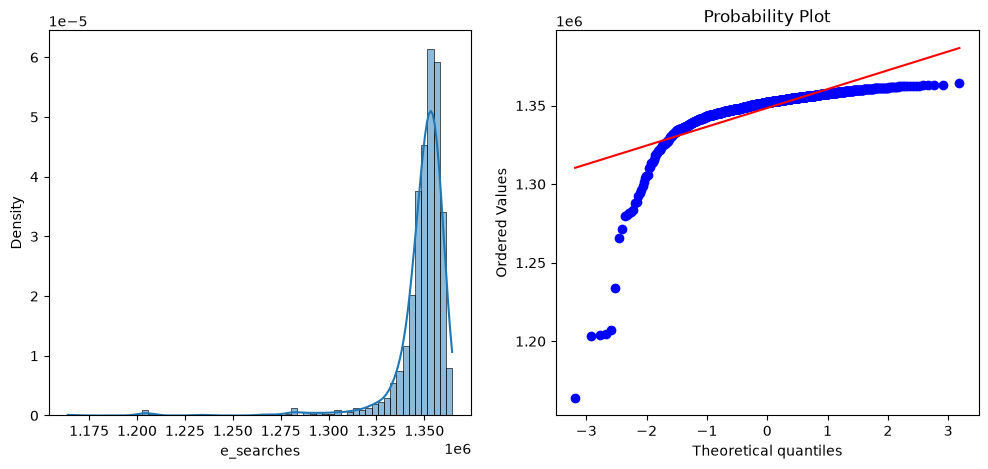

In [11]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mostly_reads.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['e_searches'], kde=True, ax=axes[0], stat="density")

stats.probplot(df['e_searches'], dist="norm", plot=axes[1])

shapiro_stat, shapiro_p = stats.shapiro(df['e_searches'])
print(shapiro_p)

candidate_distributions = {
    "norm": stats.norm,
    "lognorm": stats.lognorm,
    "expon": stats.expon,
    "weibull_min": stats.weibull_min
}

for sc_name, dist in candidate_distributions.items():
    # 1. Ajusta os parâmetros da distribuição aos dados reais
    params = dist.fit(df['e_searches'])
    
    # 2. "Congela" a distribuição desempacotando os parâmetros calculados
    frozen_dist = dist(*params)
    
    # 3. Passa o método .cdf diretamente. Não precisa mais do argumento 'args'
    ks_stat, ks_p = stats.kstest(df['e_searches'], frozen_dist.cdf)
    
    # Formata o nome bonitinho para o print
    display_name = sc_name.replace("_min", "").capitalize()
    if display_name == "Norm": display_name = "Normal"
    
    print(f"{display_name:<12} fit confidence (KS p-value): {ks_p:.4f}")

#print(df.columns)
#plt.plot(df['e_searches'])